1. Imports + Load Dataset

In [1]:
import pandas as pd #used for tabular data
import numpy as np # lib used for nuerical data computation
import matplotlib.pyplot as plt #Matplotlib is used for creating graphs and visualizations, pyplot is the part of Matplotlib that provides plotting functions.
import seaborn as sns # another visualization lib (statistical analysis , like confusion matrix)
import time

from sklearn.model_selection import train_test_split #train_test_split is used to divide your dataset into different portions.(skLearn lib provides this function)
from sklearn.pipeline import Pipeline #A Pipeline allows us to connect multiple ML steps together
from sklearn.compose import ColumnTransformer #ColumnTransformer lets us apply different preprocessing to different columns.
from sklearn.impute import SimpleImputer #SimpleImputer is used to handle missing values.
from sklearn.preprocessing import OneHotEncoder, StandardScaler #(StandardScaler: This is used to scale numerical features.)
#(one hot encoder: This is used to convert categorical data into numerical data.)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, #Out of all predictions, how many were correct?
    precision_score, #Of the customers predicted as churners, how many actually churned?
    recall_score,#Of the customers who actually churned, how many did we successfully identify
    f1_score,#Combines precision + recall into a single score.
    roc_auc_score,
    confusion_matrix
)

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head(10))
print("Shape:", df.shape)


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

2. Data Inspection + Cleaning

In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
#(count
#mean
#std
#min
#25%
#50%
#75%
#max)
print(df.describe(include="all"))


print("\nChurn Distribution:")
print(df["Churn"].value_counts())
#value_count tells how any times each unique value has appeared
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce" #If you can't convert it into a number, don't crash. Turn it into NaN
)
df = df.drop("customerID", axis=1)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Duplicate Rows: 0

Missing Values:
customerID      

3. X/y + Train/Validation/Test Split

In [3]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (4930, 19)
Validation: (1056, 19)
Testing: (1057, 19)


4. Preprocessing

In [4]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

# Check preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (4930, 45)
Validation shape: (1056, 45)
Testing shape: (1057, 45)


5. Logistic Regression

In [5]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

start = time.perf_counter()
logistic_pipeline.fit(X_train, y_train)
logistic_train_time = time.perf_counter() - start

start = time.perf_counter()
logistic_pred = logistic_pipeline.predict(X_val)
logistic_inference_time = time.perf_counter() - start

logistic_prob = logistic_pipeline.predict_proba(X_val)[:, 1]

print("Training time:", logistic_train_time)
print("Inference time:", logistic_inference_time)
print("Accuracy :", accuracy_score(y_val, logistic_pred))
print("Precision:", precision_score(y_val, logistic_pred))
print("Recall   :", recall_score(y_val, logistic_pred))
print("F1-score :", f1_score(y_val, logistic_pred))
print("ROC-AUC  :", roc_auc_score(y_val, logistic_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, logistic_pred))

Training time: 0.11085293699943577
Inference time: 0.01086916799977189
Accuracy : 0.8058712121212122
Precision: 0.6459143968871596
Recall   : 0.5928571428571429
F1-score : 0.6182495344506518
ROC-AUC  : 0.8453124999999999

Confusion Matrix:
[[685  91]
 [114 166]]


6. KNN — K=3

In [6]:
knn3_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

start = time.perf_counter()
knn3_pipeline.fit(X_train, y_train)
knn3_train_time = time.perf_counter() - start

start = time.perf_counter()
knn3_pred = knn3_pipeline.predict(X_val)
knn3_inference_time = time.perf_counter() - start

knn3_prob = knn3_pipeline.predict_proba(X_val)[:, 1]

print("Training time:", knn3_train_time)
print("Inference time:", knn3_inference_time)
print("Accuracy :", accuracy_score(y_val, knn3_pred))
print("Precision:", precision_score(y_val, knn3_pred))
print("Recall   :", recall_score(y_val, knn3_pred))
print("F1-score :", f1_score(y_val, knn3_pred))
print("ROC-AUC  :", roc_auc_score(y_val, knn3_prob))

Training time: 0.0692585799988592
Inference time: 0.08966475099987292
Accuracy : 0.7490530303030303
Precision: 0.5244299674267101
Recall   : 0.575
F1-score : 0.5485519591141397
ROC-AUC  : 0.7525358983799706


7. KNN — K=7

In [7]:
knn7_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

start = time.perf_counter()
knn7_pipeline.fit(X_train, y_train)
knn7_train_time = time.perf_counter() - start

start = time.perf_counter()
knn7_pred = knn7_pipeline.predict(X_val)
knn7_inference_time = time.perf_counter() - start

knn7_prob = knn7_pipeline.predict_proba(X_val)[:, 1]

print("Training time:", knn7_train_time)
print("Inference time:", knn7_inference_time)
print("Accuracy :", accuracy_score(y_val, knn7_pred))
print("Precision:", precision_score(y_val, knn7_pred))
print("Recall   :", recall_score(y_val, knn7_pred))
print("F1-score :", f1_score(y_val, knn7_pred))
print("ROC-AUC  :", roc_auc_score(y_val, knn7_prob))

Training time: 0.07155619099830801
Inference time: 0.029367033999733394
Accuracy : 0.7727272727272727
Precision: 0.5684931506849316
Recall   : 0.5928571428571429
F1-score : 0.5804195804195804
ROC-AUC  : 0.8060866163475701


8. Decision Tree — Shallow

In [9]:
dt_shallow_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

start = time.perf_counter()
dt_shallow_pipeline.fit(X_train, y_train)
dt_shallow_train_time = time.perf_counter() - start

start = time.perf_counter()
dt_shallow_pred = dt_shallow_pipeline.predict(X_val)
dt_shallow_inference_time = time.perf_counter() - start

dt_shallow_prob = dt_shallow_pipeline.predict_proba(X_val)[:, 1]

dt_shallow_train_pred = dt_shallow_pipeline.predict(X_train)

print("Training time:", dt_shallow_train_time)
print("Inference time:", dt_shallow_inference_time)
print("Accuracy :", accuracy_score(y_val, dt_shallow_pred))
print("Precision:", precision_score(y_val, dt_shallow_pred))
print("Recall   :", recall_score(y_val, dt_shallow_pred))
print("F1-score :", f1_score(y_val, dt_shallow_pred))
print("ROC-AUC  :", roc_auc_score(y_val, dt_shallow_prob))

print("Training Accuracy:",
      accuracy_score(y_train, dt_shallow_train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, dt_shallow_pred))

Training time: 0.09193127700018522
Inference time: 0.01784023200161755
Accuracy : 0.7935606060606061
Precision: 0.7012987012987013
Recall   : 0.38571428571428573
F1-score : 0.4976958525345622
ROC-AUC  : 0.8246203055964654
Training Accuracy: 0.7914807302231237
Validation Accuracy: 0.7935606060606061


9. Decision Tree — Deep

In [11]:
dt_deep_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=15,
        random_state=42
    ))
])

start = time.perf_counter()
dt_deep_pipeline.fit(X_train, y_train)
dt_deep_train_time = time.perf_counter() - start

start = time.perf_counter()
dt_deep_pred = dt_deep_pipeline.predict(X_val)
dt_deep_inference_time = time.perf_counter() - start

dt_deep_prob = dt_deep_pipeline.predict_proba(X_val)[:, 1]

dt_deep_train_pred = dt_deep_pipeline.predict(X_train)

print("Training time:", dt_deep_train_time)
print("Inference time:", dt_deep_inference_time)
print("Accuracy :", accuracy_score(y_val, dt_deep_pred))
print("Precision:", precision_score(y_val, dt_deep_pred))
print("Recall   :", recall_score(y_val, dt_deep_pred))
print("F1-score :", f1_score(y_val, dt_deep_pred))
print("ROC-AUC  :", roc_auc_score(y_val, dt_deep_prob))

print("Training Accuracy:",
      accuracy_score(y_train, dt_deep_train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, dt_deep_pred))

Training time: 0.10653571800139616
Inference time: 0.020737626000482123
Accuracy : 0.7244318181818182
Precision: 0.48
Recall   : 0.4714285714285714
F1-score : 0.4756756756756757
ROC-AUC  : 0.6637564432989691
Training Accuracy: 0.9669371196754564
Validation Accuracy: 0.7244318181818182


10. Random Forest

In [13]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

start = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
rf_train_time = time.perf_counter() - start

start = time.perf_counter()
rf_pred = rf_pipeline.predict(X_val)
rf_inference_time = time.perf_counter() - start

rf_prob = rf_pipeline.predict_proba(X_val)[:, 1]

rf_train_pred = rf_pipeline.predict(X_train)

print("Training time:", rf_train_time)
print("Inference time:", rf_inference_time)
print("Accuracy :", accuracy_score(y_val, rf_pred))
print("Precision:", precision_score(y_val, rf_pred))
print("Recall   :", recall_score(y_val, rf_pred))
print("F1-score :", f1_score(y_val, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_val, rf_prob))

print("Training Accuracy:",
      accuracy_score(y_train, rf_train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_pred))

Training time: 0.6147574899987376
Inference time: 0.03494222500012256
Accuracy : 0.7784090909090909
Precision: 0.5991379310344828
Recall   : 0.49642857142857144
F1-score : 0.54296875
ROC-AUC  : 0.8126610824742269
Training Accuracy: 0.9979716024340771
Validation Accuracy: 0.7784090909090909

Confusion Matrix:
[[683  93]
 [141 139]]


11. Gradient Boosting

In [14]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ))
])

start = time.perf_counter()
gb_pipeline.fit(X_train, y_train)
gb_train_time = time.perf_counter() - start

start = time.perf_counter()
gb_pred = gb_pipeline.predict(X_val)
gb_inference_time = time.perf_counter() - start

gb_prob = gb_pipeline.predict_proba(X_val)[:, 1]

gb_train_pred = gb_pipeline.predict(X_train)

print("Training time:", gb_train_time)
print("Inference time:", gb_inference_time)
print("Accuracy :", accuracy_score(y_val, gb_pred))
print("Precision:", precision_score(y_val, gb_pred))
print("Recall   :", recall_score(y_val, gb_pred))
print("F1-score :", f1_score(y_val, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_val, gb_prob))

print("Training Accuracy:",
      accuracy_score(y_train, gb_train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, gb_pred))

Training time: 1.096911356000419
Inference time: 0.020633019999877433
Accuracy : 0.8011363636363636
Precision: 0.65625
Recall   : 0.525
F1-score : 0.5833333333333334
ROC-AUC  : 0.8478691089837996
Training Accuracy: 0.8318458417849899
Validation Accuracy: 0.8011363636363636


12. XGBoost

In [15]:
from xgboost import XGBClassifier

# Create XGBoost pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Training
start = time.perf_counter()

xgb_pipeline.fit(X_train, y_train)

xgb_train_time = time.perf_counter() - start

# Validation prediction
start = time.perf_counter()

xgb_pred = xgb_pipeline.predict(X_val)

xgb_inference_time = time.perf_counter() - start

# Prediction probabilities
xgb_prob = xgb_pipeline.predict_proba(X_val)[:, 1]

# Metrics
print("Training time:", xgb_train_time, "seconds")
print("Inference time:", xgb_inference_time, "seconds")

print("Accuracy :", accuracy_score(y_val, xgb_pred))
print("Precision:", precision_score(y_val, xgb_pred))
print("Recall   :", recall_score(y_val, xgb_pred))
print("F1-score :", f1_score(y_val, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_val, xgb_prob))

# Training vs validation accuracy
xgb_train_pred = xgb_pipeline.predict(X_train)

print("Training Accuracy:",
      accuracy_score(y_train, xgb_train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, xgb_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, xgb_pred)) 

Training time: 0.14821243199912715 seconds
Inference time: 0.023217824000312248 seconds
Accuracy : 0.7897727272727273
Precision: 0.6208333333333333
Recall   : 0.5321428571428571
F1-score : 0.573076923076923
ROC-AUC  : 0.8359421023564064
Training Accuracy: 0.8760649087221095
Validation Accuracy: 0.7897727272727273

Confusion Matrix:
[[685  91]
 [131 149]]


13. SVM — Without Scaling vs With Scaling

The assignment requires comparing SVM performance with and without appropriate feature scaling.
The unscaled version uses the same imputation/encoding but does not standardize numerical features.
The scaled version uses the existing numerical pipeline with StandardScaler.


In [16]:
# -----------------------------
# SVM WITHOUT FEATURE SCALING
# -----------------------------

numerical_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_unscaled = ColumnTransformer([
    ("num", numerical_pipeline_unscaled, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

svm_unscaled_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", SVC(probability=True, random_state=42))
])

start = time.perf_counter()
svm_unscaled_pipeline.fit(X_train, y_train)
svm_unscaled_train_time = time.perf_counter() - start

start = time.perf_counter()
svm_unscaled_pred = svm_unscaled_pipeline.predict(X_val)
svm_unscaled_inference_time = time.perf_counter() - start

svm_unscaled_prob = svm_unscaled_pipeline.predict_proba(X_val)[:, 1]

print("===== SVM WITHOUT SCALING =====")
print("Training time:", svm_unscaled_train_time)
print("Inference time:", svm_unscaled_inference_time)
print("Accuracy :", accuracy_score(y_val, svm_unscaled_pred))
print("Precision:", precision_score(y_val, svm_unscaled_pred, zero_division=0))
print("Recall   :", recall_score(y_val, svm_unscaled_pred, zero_division=0))
print("F1-score :", f1_score(y_val, svm_unscaled_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_val, svm_unscaled_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, svm_unscaled_pred))

# -----------------------------
# SVM WITH FEATURE SCALING
# -----------------------------

svm_scaled_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

start = time.perf_counter()
svm_scaled_pipeline.fit(X_train, y_train)
svm_scaled_train_time = time.perf_counter() - start

start = time.perf_counter()
svm_scaled_pred = svm_scaled_pipeline.predict(X_val)
svm_scaled_inference_time = time.perf_counter() - start

svm_scaled_prob = svm_scaled_pipeline.predict_proba(X_val)[:, 1]

print("\n===== SVM WITH SCALING =====")
print("Training time:", svm_scaled_train_time)
print("Inference time:", svm_scaled_inference_time)
print("Accuracy :", accuracy_score(y_val, svm_scaled_pred))
print("Precision:", precision_score(y_val, svm_scaled_pred, zero_division=0))
print("Recall   :", recall_score(y_val, svm_scaled_pred, zero_division=0))
print("F1-score :", f1_score(y_val, svm_scaled_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_val, svm_scaled_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, svm_scaled_pred))


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


===== SVM WITHOUT SCALING =====
Training time: 6.160952678001195
Inference time: 0.4937978470006783
Accuracy : 0.7348484848484849
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC-AUC  : 0.800402706185567

Confusion Matrix:
[[776   0]
 [280   0]]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



===== SVM WITH SCALING =====
Training time: 5.582373897999787
Inference time: 0.4511388539995096
Accuracy : 0.7992424242424242
Precision: 0.6545454545454545
Recall   : 0.5142857142857142
F1-score : 0.576
ROC-AUC  : 0.808608707658321

Confusion Matrix:
[[700  76]
 [136 144]]


14. Underfitting and Overfitting Experiment

A very shallow tree is included to demonstrate high bias/underfitting, while the existing deep tree demonstrates high variance/overfitting.


In [17]:
underfit_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=1, random_state=42))
])

start = time.perf_counter()
underfit_pipeline.fit(X_train, y_train)
underfit_train_time = time.perf_counter() - start

underfit_train_pred = underfit_pipeline.predict(X_train)
underfit_val_pred = underfit_pipeline.predict(X_val)
underfit_val_prob = underfit_pipeline.predict_proba(X_val)[:, 1]

underfit_inference_time = None
start = time.perf_counter()
_ = underfit_pipeline.predict(X_val)
underfit_inference_time = time.perf_counter() - start

print("===== UNDERFITTING MODEL: DECISION TREE max_depth=1 =====")
print("Training Accuracy:", accuracy_score(y_train, underfit_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, underfit_val_pred))
print("Validation F1:", f1_score(y_val, underfit_val_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, underfit_val_prob))
print("Training time:", underfit_train_time)
print("Inference time:", underfit_inference_time)

print("\n===== OVERFITTING MODEL: DECISION TREE max_depth=15 =====")
print("Training Accuracy:", accuracy_score(y_train, dt_deep_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, dt_deep_pred))
print("Validation F1:", f1_score(y_val, dt_deep_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, dt_deep_prob))


===== UNDERFITTING MODEL: DECISION TREE max_depth=1 =====
Training Accuracy: 0.734685598377282
Validation Accuracy: 0.7348484848484849
Validation F1: 0.0
Validation ROC-AUC: 0.7288475699558173
Training time: 0.1511469439992652
Inference time: 0.012195399998745415

===== OVERFITTING MODEL: DECISION TREE max_depth=15 =====
Training Accuracy: 0.9669371196754564
Validation Accuracy: 0.7244318181818182
Validation F1: 0.4756756756756757
Validation ROC-AUC: 0.6637564432989691


15. Complete Validation Results Table

This table is generated directly from the trained models rather than manually entering metric values. This prevents missing/incorrect values in the final comparison.


In [18]:
def collect_metrics(name, model, X_eval, y_eval, train_time):
    start = time.perf_counter()
    pred = model.predict(X_eval)
    inference_time = time.perf_counter() - start

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_eval)[:, 1]
    else:
        prob = None

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1-score": f1_score(y_eval, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, prob) if prob is not None else np.nan,
        "Training Time": train_time,
        "Inference Time": inference_time
    }

validation_models = [
    ("Logistic Regression", logistic_pipeline, logistic_train_time),
    ("KNN (K=3)", knn3_pipeline, knn3_train_time),
    ("KNN (K=7)", knn7_pipeline, knn7_train_time),
    ("Shallow Decision Tree", dt_shallow_pipeline, dt_shallow_train_time),
    ("Deep Decision Tree", dt_deep_pipeline, dt_deep_train_time),
    ("Random Forest", rf_pipeline, rf_train_time),
    ("Gradient Boosting", gb_pipeline, gb_train_time),
    ("XGBoost", xgb_pipeline, xgb_train_time),
    ("SVM (Unscaled)", svm_unscaled_pipeline, svm_unscaled_train_time),
    ("SVM (Scaled)", svm_scaled_pipeline, svm_scaled_train_time)
]

validation_results = pd.DataFrame([
    collect_metrics(name, model, X_val, y_val, train_time)
    for name, model, train_time in validation_models
]).set_index("Model")

display(validation_results.sort_values("F1-score", ascending=False))

print("\nBest validation model by F1-score:")
print(validation_results["F1-score"].idxmax())

print("\nBest validation model by ROC-AUC:")
print(validation_results["ROC-AUC"].idxmax())

print("\nFastest inference:")
print(validation_results["Inference Time"].idxmin())


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time,Inference Time
Model,,,,,,,
Logistic Regression,0.805871,0.645914,0.592857,0.618250,0.845312,0.110853,0.026810
Gradient Boosting,0.801136,0.656250,0.525000,0.583333,0.847869,1.096911,0.015845
KNN (K=7),0.772727,0.568493,0.592857,0.580420,0.806087,0.071556,0.026092
SVM (Scaled),0.799242,0.654545,0.514286,0.576000,0.808609,5.582374,0.465549
XGBoost,0.789773,0.620833,0.532143,0.573077,0.835942,0.148212,0.012349
KNN (K=3),0.749053,0.524430,0.575000,0.548552,0.752536,0.069259,0.027119
Random Forest,0.778409,0.599138,0.496429,0.542969,0.812661,0.614757,0.036881
Shallow Decision Tree,0.793561,0.701299,0.385714,0.497696,0.824620,0.091931,0.013625
Deep Decision Tree,0.724432,0.480000,0.471429,0.475676,0.663756,0.106536,0.015298



Best validation model by F1-score:
Logistic Regression

Best validation model by ROC-AUC:
Gradient Boosting

Fastest inference:
XGBoost


16. Final Test-Set Evaluation

The test set is used only after model selection on the validation set. All models are evaluated consistently so the final generalization comparison is fair.


In [20]:
test_models = {
    "Logistic Regression": logistic_pipeline,
    "KNN (K=3)": knn3_pipeline,
    "KNN (K=7)": knn7_pipeline,
    "Shallow Decision Tree": dt_shallow_pipeline,
    "Deep Decision Tree": dt_deep_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline,
    "SVM (Unscaled)": svm_unscaled_pipeline,
    "SVM (Scaled)": svm_scaled_pipeline
}

test_rows = []
test_predictions = {}
test_probabilities = {}

for name, model in test_models.items():
    start = time.perf_counter()
    pred = model.predict(X_test)
    inference_time = time.perf_counter() - start

    prob = model.predict_proba(X_test)[:, 1]

    test_predictions[name] = pred
    test_probabilities[name] = prob

    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Inference Time": inference_time
    })

test_results = pd.DataFrame(test_rows).set_index("Model")

display(test_results.sort_values("F1-score", ascending=False))

print("\nBest final test model by F1-score:")
print(test_results["F1-score"].idxmax())

print("\nBest final test model by ROC-AUC:")
print(test_results["ROC-AUC"].idxmax())


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Inference Time
Model,,,,,,
Logistic Regression,0.811731,0.689815,0.530249,0.599598,0.844755,0.033756
XGBoost,0.789972,0.631111,0.505338,0.561265,0.821537,0.012968
KNN (K=7),0.766320,0.564885,0.526690,0.545120,0.801223,0.023162
SVM (Scaled),0.794702,0.663265,0.462633,0.545073,0.795706,0.467910
Random Forest,0.788079,0.635071,0.476868,0.544715,0.813408,0.031335
KNN (K=3),0.755913,0.540351,0.548043,0.544170,0.740042,0.031883
Gradient Boosting,0.789972,0.643902,0.469751,0.543210,0.834270,0.013488
Deep Decision Tree,0.744560,0.520755,0.491103,0.505495,0.683281,0.012291
Shallow Decision Tree,0.781457,0.681159,0.334520,0.448687,0.809725,0.010865



Best final test model by F1-score:
Logistic Regression

Best final test model by ROC-AUC:
Logistic Regression


17. Confusion Matrices

Confusion matrices are plotted for every model to show true negatives, false positives, false negatives, and true positives.


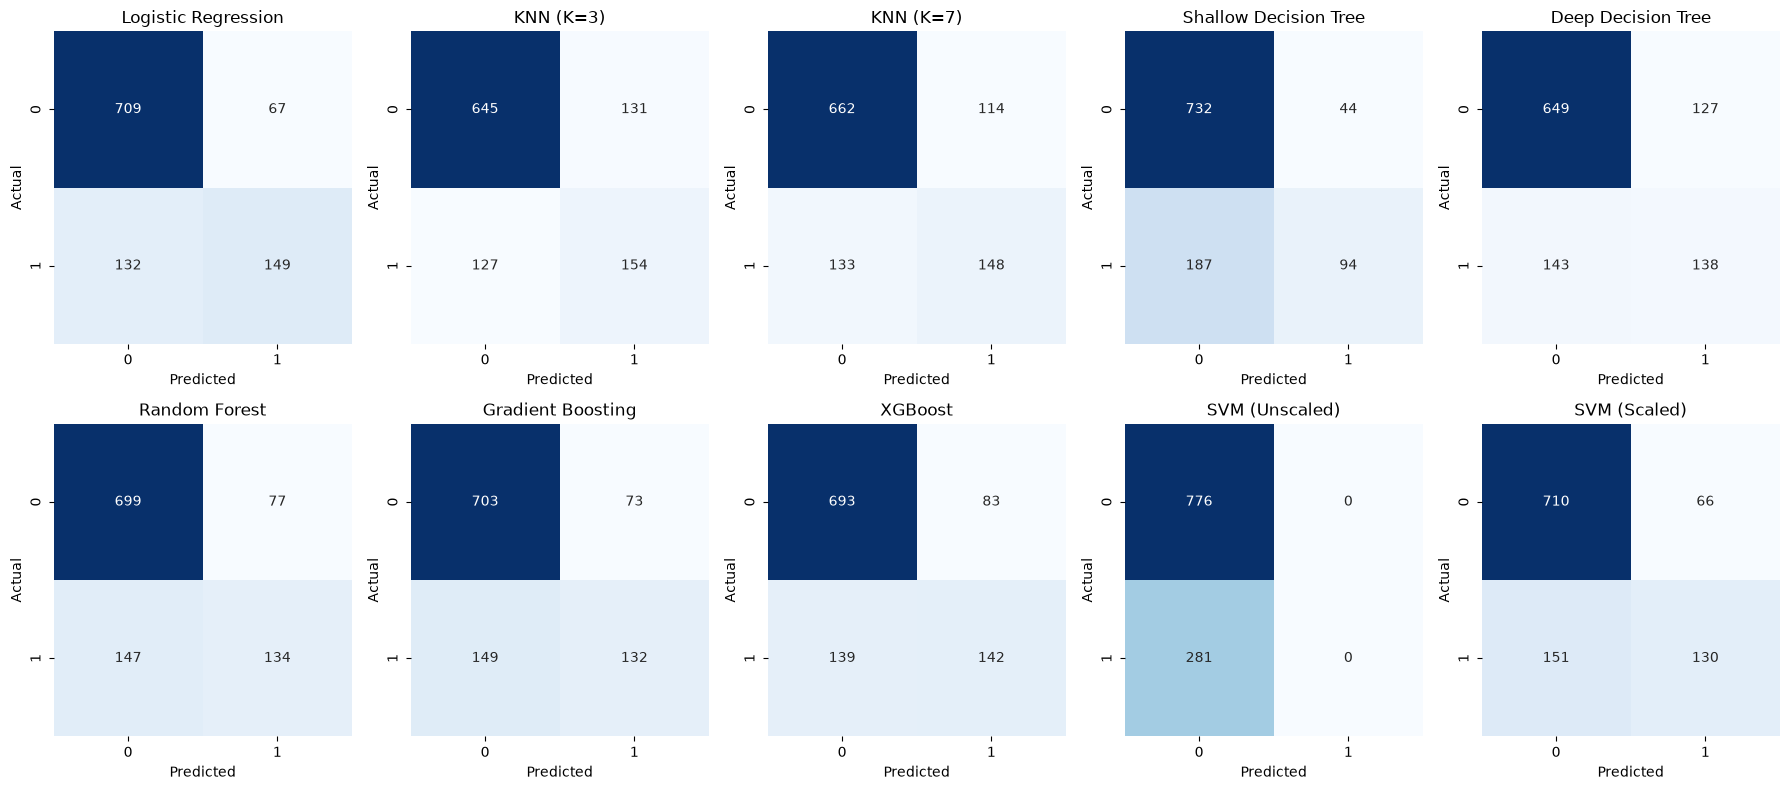

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


18. ROC Curve Comparison


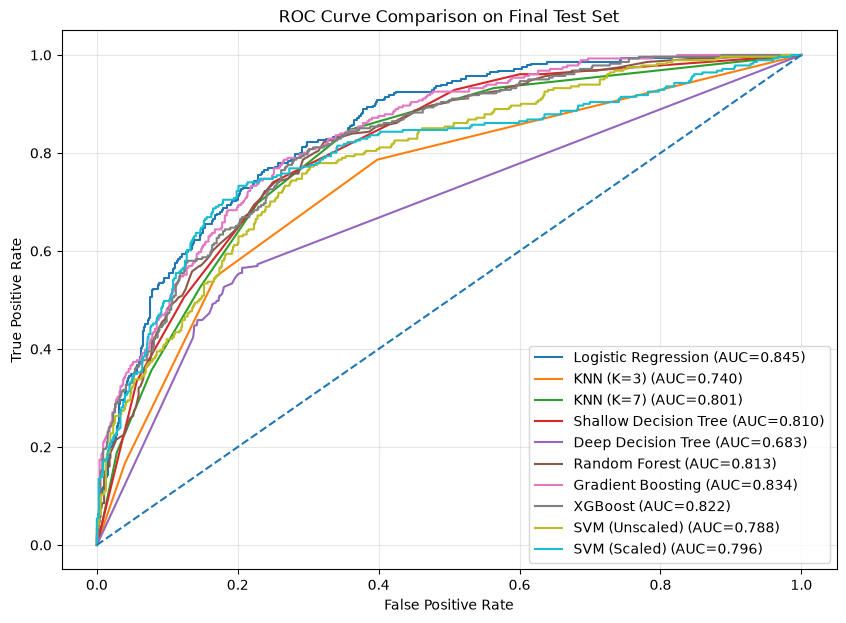

In [22]:
plt.figure(figsize=(10, 7))

for name, prob in test_probabilities.items():
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison on Final Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


19. Training and Inference Time Comparison


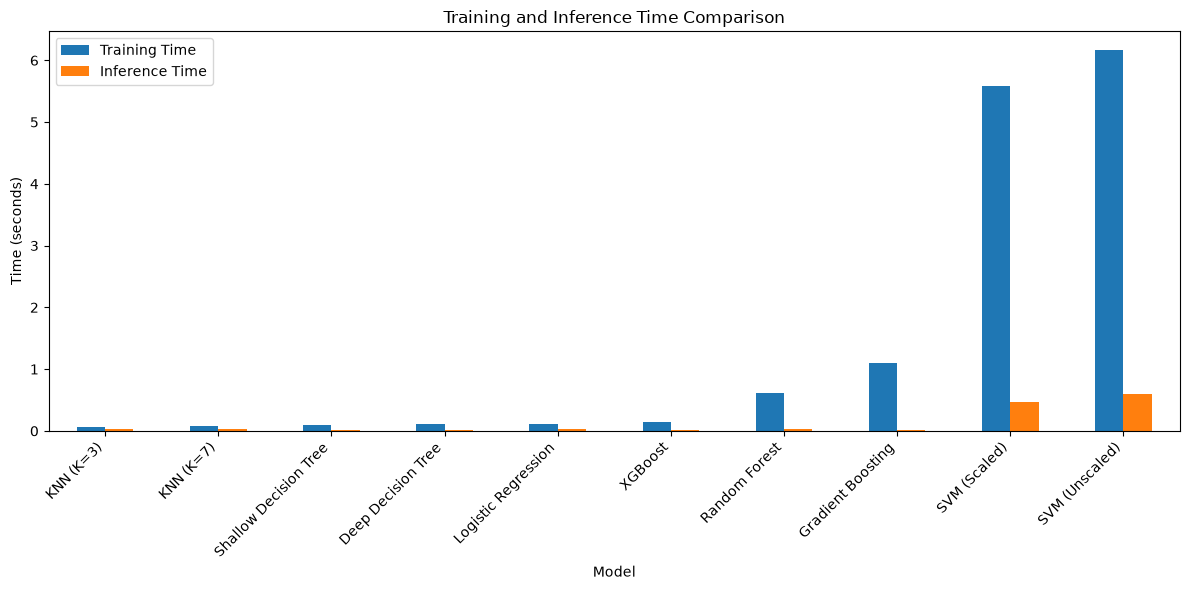

Fastest training model: KNN (K=3)
Fastest inference model: XGBoost


In [23]:
timing_df = validation_results[["Training Time", "Inference Time"]].copy()

timing_df.sort_values("Training Time").plot(
    kind="bar",
    figsize=(12, 6),
    title="Training and Inference Time Comparison"
)
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Fastest training model:", validation_results["Training Time"].idxmin())
print("Fastest inference model:", validation_results["Inference Time"].idxmin())


20. Training vs Validation Performance and Model Selection Observations


In [24]:
train_accuracy = {}

for name, model, _ in validation_models:
    train_pred = model.predict(X_train)
    train_accuracy[name] = accuracy_score(y_train, train_pred)

train_val_df = validation_results[["Accuracy", "F1-score", "ROC-AUC"]].copy()
train_val_df["Training Accuracy"] = pd.Series(train_accuracy)
train_val_df["Accuracy Gap"] = (
    train_val_df["Training Accuracy"] - train_val_df["Accuracy"]
)

display(train_val_df.sort_values("F1-score", ascending=False))

best_validation_f1 = validation_results["F1-score"].idxmax()
best_validation_auc = validation_results["ROC-AUC"].idxmax()
best_test_f1 = test_results["F1-score"].idxmax()
best_test_auc = test_results["ROC-AUC"].idxmax()
fastest_inference = validation_results["Inference Time"].idxmin()
most_interpretable = "Decision Tree"

print("===== AUTOMATIC OBSERVATIONS =====")
print("Best validation model by F1-score:", best_validation_f1)
print("Best validation model by ROC-AUC:", best_validation_auc)
print("Best final test model by F1-score:", best_test_f1)
print("Best final test model by ROC-AUC:", best_test_auc)
print("Fastest inference model:", fastest_inference)
print("Most interpretable model:", most_interpretable)

print("\nClass distribution:")
print(y.value_counts(normalize=True).rename({0: "No Churn", 1: "Churn"}) * 100)

print("\nInterpretation:")
print("- Accuracy should not be considered alone because the target is imbalanced.")
print("- Precision, recall, F1-score and ROC-AUC are useful for evaluating churn detection.")
print("- The deep tree's large training-validation gap is evidence of high variance/overfitting.")
print("- The max_depth=1 tree is used as the high-bias/underfitting comparison.")
print("- Decision Trees are more interpretable than ensemble and kernel-based models.")


,Accuracy,F1-score,ROC-AUC,Training Accuracy,Accuracy Gap
Model,,,,,
Logistic Regression,0.805871,0.618250,0.845312,0.804057,-0.001814
Gradient Boosting,0.801136,0.583333,0.847869,0.831846,0.030709
KNN (K=7),0.772727,0.580420,0.806087,0.822921,0.050194
SVM (Scaled),0.799242,0.576000,0.808609,0.823935,0.024693
XGBoost,0.789773,0.573077,0.835942,0.876065,0.086292
KNN (K=3),0.749053,0.548552,0.752536,0.859026,0.109973
Random Forest,0.778409,0.542969,0.812661,0.997972,0.219563
Shallow Decision Tree,0.793561,0.497696,0.824620,0.791481,-0.002080
Deep Decision Tree,0.724432,0.475676,0.663756,0.966937,0.242505


===== AUTOMATIC OBSERVATIONS =====
Best validation model by F1-score: Logistic Regression
Best validation model by ROC-AUC: Gradient Boosting
Best final test model by F1-score: Logistic Regression
Best final test model by ROC-AUC: Logistic Regression
Fastest inference model: XGBoost
Most interpretable model: Decision Tree

Class distribution:
Churn
No Churn    73.463013
Churn       26.536987
Name: proportion, dtype: float64

Interpretation:
- Accuracy should not be considered alone because the target is imbalanced.
- Precision, recall, F1-score and ROC-AUC are useful for evaluating churn detection.
- The deep tree's large training-validation gap is evidence of high variance/overfitting.
- The max_depth=1 tree is used as the high-bias/underfitting comparison.
- Decision Trees are more interpretable than ensemble and kernel-based models.
